# Week 6

[Good news everyone!](https://www.youtube.com/watch?v=vLxMB8xmWSI) We've had heavy exercise load the last few weeks, so it's time for an lighter day today `:)`

The purpose of today's class is to explore data using **interactive visualizations**. Interactivity is a key part of modern dataviz. It lets users of your visualizations get their own feel for the data, creating richer experiences where people can expose more of the data by exploring.

## Today

This lecture covers:

1. **Explanatory data visualization**: A video lecture on the principles of interactive, explanatory dataviz: overview first, zoom and filter, details on demand.
2. **Interactive visualizations with Plotly**: You'll rebuild the hourly crime distributions from Week 2 as interactive plots, and then take things further with animated visualizations.
3. **Narrative data visualization**: Reading from a key research paper on how to tell stories with data.

## Part 1: Explanatory Data Visualization

Starting this week, we'll be playing around with *explanatory data visualization*. Roughly speaking, this means using data visualization to communicate your results to others. Thus, there are new things to think about.

Until today we have worked with static data visualization. However, exploratory data analysis means being able to explore the multi-faceted nature of data, and *interactive dataviz* is a handy tool to do it! It allows the user to play with the data without knowing how to write code: toggle the view, zoom, drag, show more details. These are a key part of modern data visualization.

The video below provides context about these points.

We start with the video and then read a bit from a scientific article about types of explanatory dataviz. (*The video is from an old version of the class that used D3, so just ignore those parts.*)

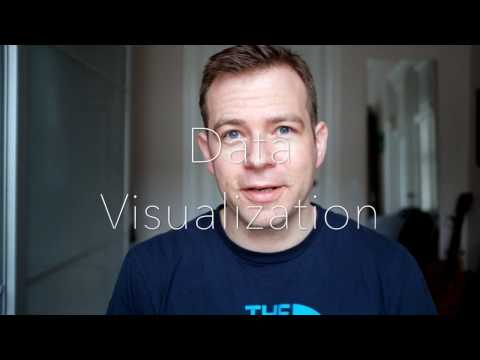

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('yHKYMGwefso', width=800, height=450)

> *Exercise 1.1*: Explanatory data visualization.
> * What are the three key elements to keep in mind when you design an explanatory visualization?
>   * The three key elements are:
>       - What is the result you want to communicate
>       - Allow exploration 
>       - Know your readers and design for audience
> * In the video I talk about (1) *overview first*, (2) *zoom and filter*, (3) *details on demand*.
>   - Go online and find a visualization that follows these principles (don't use one from the video).
>   - Explain how your example achieves (1)-(3). It might be useful to use screenshots to illustrate your explanation.
>   * A good example is [this](https://africa.climatemobility.org/explore-the-data) website. It let's you first select the geographic and socioeconomic datasets that you want to visualize the data over the African continent, then it lets you zoom in specific areas and lastly select different filters to update the visualization. 
> * Explain in your own words: How is explanatory data analysis different from exploratory data analysis?
>   * Explanatory data analysis aims to show insights in a way such that they are easy to understand and visualize for everyone. Exploratory data analysis aims to find specific patterns and details that help scientist come to theories and conclusion, it's done before respect to explanatory data analysis that shows the results of the studies. 
> **Note**. Keep your answers to the questions above short and sweet.

<div class="alert alert-block alert-info">
Try to answer these using your human brain, don't use an LLM.
</div>

## Part 2: Interactive Visualizations with Plotly

You already know Plotly from Week 5, where you used it to create choropleth maps. Now we'll use it for a different purpose: building interactive charts that let users explore temporal patterns in the crime data.

Plotly is great for this because it gives you interactivity for free: hover tooltips, zoom, pan, and clickable legends all come built-in. This means you can focus on the *data* and the *story*, not on wiring up interactive widgets.

If you need a refresher, the [Plotly Express documentation](https://plotly.com/python/plotly-express/) is a good starting point. But I hope you'll find that you remember more from Week 5 than you think 🤟

**Note**: There are many other ways to create interactive visualizations. I'll highlight two

* *[Altair](https://altair-viz.github.io/)*
* *[Bokeh](https://docs.bokeh.org/en/latest/)* (Bokeh is nice when you want a bit more lower-level control in Python, we've used this in the class previously).

If you want to use these when we get further in the class and you're creating your  own visualizations in the final project, that is OK.

Anyway. **Let's get started**. As always we'll focus on the SF crime data, and your personal focus crimes. Data for whole years only.

In [1]:
import plotly.express as px
import pandas as pd
import os
FOCUS_CRIMES = ["assault", "arson", "burglary", "embezzlement", "fraud", "gambling", 
                      "liquor laws", "missing person", "non-criminal", 
                      "prostitution", "recovered vehicle", "robbery", "stolen property", 
                      "suicide", "suspicious occ", "disorderly conduct", "motor vehicle theft", 
                      "larceny theft", "warrant", "forgery and counterfeiting"]
FOCUS_CRIMES_MINUS_NONCRIMINAL = [crime for crime in FOCUS_CRIMES if crime != "non-criminal"]
df = pd.read_csv(os.path.join(os.getcwd(), '..', 'files', 'Merged_Police_Incidents_2003_to_Present.csv'))
data_focus = df[df['Mapped Category'].isin(FOCUS_CRIMES_MINUS_NONCRIMINAL)]
data_focus.head()

,Row ID,Incident Datetime,Incident Day of Week,Incident Number,Incident Code,Incident Category,Incident Description,Resolution,Intersection,Police District,Point,Mapped Category,Year,Month,Year-Month,Dataset
1,3040688210125,2003-01-01 00:01:00,wednesday,30406882,10125,fraud,"false pretenses, grand theft",none,200 block of winston dr,taraval,POINT (-122.477976682 37.726934635),fraud,2003,1,2003-01,Historical
2,6004185606373,2003-01-01 00:01:00,wednesday,60041856,6373,larceny/theft,petty theft of property,none,800 block of bryant st,southern,POINT (-122.403404791 37.775420707),larceny theft,2003,1,2003-01,Historical
4,3039997006304,2003-01-01 00:01:00,wednesday,30399970,6304,larceny/theft,grand theft from a building,none,1800 block of pine st,northern,POINT (-122.426246093 37.78883457),larceny theft,2003,1,2003-01,Historical
5,6003545109020,2003-01-01 00:01:00,wednesday,60035451,9020,forgery/counterfeiting,"checks, make or pass fictitious",not prosecuted,2400 block of folsom st,mission,POINT (-122.414683321 37.758077444),forgery and counterfeiting,2003,1,2003-01,Historical
6,3006321609015,2003-01-01 00:01:00,wednesday,30063216,9015,forgery/counterfeiting,"checks, forgery (felony)",none,100 block of dakota st,bayview,POINT (-122.395635436 37.753564575),forgery and counterfeiting,2003,1,2003-01,Historical


The goal is to create an *interactive* visualization of how your Personal Focus Crimes distribute across the 24 hours of the day — similar to what you plotted in Week 2's Exercise 3.1, but now set up so the user can play with the data. The key feature: you can click on crime types in the legend to show and hide them, making it possible to directly compare patterns across crime types.

> *Exercise 2.1*: New version weekly patterns. To complete the exercise, follow the steps below.

<div class="alert alert-block alert-info">
Try to do this yourself before asking an LLM — you already know Plotly from Week 5, and the data preparation is similar to what you did in Week 2. Use your LLM as a helper if you get stuck, not as an end-to-end solution.
</div>

> ### Data prep
>
> A key step is to set up the data right. I recommend the following workflow:
>
> 1. Take the data for the period you want to plot, group it by hour-of-the-day for each of your Personal Focus Crimes. We'll use the entire period by default, but you may use another period if you'd like.
> 2. We want to compare *shapes* of distributions across crime types, not absolute numbers, so we'll work on **normalized data**:
>    * To normalize within a crime category, divide the count for each hour by the total number of that crime type. (For example, in the `Drug Offense` category, take the count of drug offenses in the midnight-to-1am hour and divide by the total number of drug offenses across all hours, etc)
>    * Note that when you normalize the data, you can interpret your data as a probability distribution, where each hour shows the probability that a crime will happen at that time.
>    * Your life will be easiest if you organize your data in **long format** — a DataFrame with columns like `Hour`, `CrimeType`, and `NormalizedCount`. If you have it in wide format (one column per crime type), look into [`pd.melt()`](https://pandas.pydata.org/docs/reference/api/pandas.melt.html) to reshape it.
>
> ### Creating the plot
>
> You'll use `px.bar` from Plotly Express — the same library you used for choropleth maps in Week 5. A few things to think about:
>
> * With many crime types, placing bars side-by-side for each hour produces tiny, unreadable bars. Look into Plotly's different [`barmode`](https://plotly.com/python/bar-charts/) options for a better approach. Adding some transparency will help when bars overlap.
> * The plot is more useful if it starts "empty" (all data/traces hidden) so the user can build up comparisons by clicking legend items one at a time. Look into Plotly's `visible` trace property to achieve this.
> * If all traces start hidden, Plotly has no data to auto-scale from, so your axes will not be meaningful. You'll need to set `range_x` and `range_y` explicitly. Think about what sensible values would be for 24 hours of data with normalized counts.
> * Place the legend where it doesn't obscure the data or the axis tick values. <font color=gray>It's OK to ask your LLM for help with legend placement.</font>
>
> It's hard to explain what I'm looking for, so here's my version so you have an idea. You plot doesn't have to look exactly like that, it's just so you have a sense of what I'm looking for and a picture's worth 1000 words.
> 
> ![example gif](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/example.gif)
> 
> ### Think about your beautiful creation
>
> 3. Try clicking on the crime types in the legend. Try single-clicking (toggles one trace) and double-clicking (isolates one trace). 
> 4. Hover over the bars — what information does the tooltip show?
>      * The crime type and the x, y values
> 5. Comment on what you see:
>    * Which crime types peak at similar hours? Which ones have very different patterns?
>       * There are crimes that are typically done at night like Robbery, Prostitution, Burglary and many others, while a few peak in the working hours of the day like Embezzlement, Forgery and Counterfeiting, Fraud and Gambling.
>    * Does anything surprise you compared to what you saw in Week 2?
>       * Not a specific surprise but this is for sure a better way to visualize data respect to exercise 3.1 in week 2. The normalization and the interactive window help a lot in comparing different crime types.
>    * How does the interactivity (toggling, hovering, zooming) change your experience of exploring this data compared to the static plots from Week 2?
>       * It increases the capacity to compare on a finer level between specific crime types or the overall criminal activity without cluttering the plot if not needed or wanted. The hovering is also helpful to read exact values and be precise if needed to report these values later on. 

In [2]:
data_focus['Hour'] = pd.to_datetime(data_focus['Incident Datetime']).dt.hour
hourly_counts = (
    data_focus
    .groupby(['Mapped Category', 'Hour'])
    .size()
    .reset_index(name='Count')
)
totals = hourly_counts.groupby('Mapped Category')['Count'].transform('sum')
hourly_counts['NormalizedCount'] = hourly_counts['Count'] / totals

fig = px.bar(
    hourly_counts,
    x='Hour',
    y='NormalizedCount',
    color='Mapped Category',
    barmode='overlay',
    opacity=0.5,
    title='Normalized Hourly Distribution of Focus Crimes (2003-Present)',
    labels={'NormalizedCount': 'Probability', 'Hour': 'Hour of Day', 'Mapped Category': 'Crime Type'},
    range_x=[-0.5, 23.5],
    range_y=[0, 0.15],
)
fig.update_traces(visible='legendonly')
fig.update_layout(
    legend=dict(
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02,
    ),
    xaxis=dict(tickmode='linear', tick0=0, dtick=1),
    margin=dict(r=200),
)
fig.show()
fig.write_html("crime_hourly_interactive.html", include_plotlyjs='cdn')

> *Exercise 2.2*: Animated crime patterns.
>
> One of Plotly's powerful features is built-in animation. Let's use it to show how hourly crime patterns have changed over time.
>
> * Take the concept of normalized hourly distributions, but now compute one **separately for each year** (still for each of your Personal Focus Crimes).
>    * Take a look at the yearly counts. If some crime-types drop precipitously at some point, it might create noisy plots.
> * Create an animated **line chart** using Plotly Express's `animation_frame` parameter. Each frame should show one year's hourly distribution. Here's a sense of how to build the animation:
>
> ```python
> fig = px.line(your_dataframe, 
>              x='Hour', y='NormalizedCount', color='CrimeType',
>              animation_frame='Year',
>              title='Come up with an appropriate title!',
>              range_y=[0, 0.2])
> fig.show()
> ```
>
> * **Important**: Set `range_y` to fix the y-axis range across all frames. Without this, Plotly will auto-scale each frame independently, which makes it difficult/impossible to compare across years. (This is a real-world pitfall — animated charts that silently re-scale their axes can be deeply misleading. Remember the perceptual errors discussion from Week 5?)
> * With 9+ crime types on screen at once, the plot can get crowded. Consider starting with only one or two traces visible and letting the user toggle the rest on via the legend. You already know how to use `fig.update_traces(visible='legendonly')` — but for animated charts you'll also need to set visibility on each animation frame. <font color=gray>It's fine to ask your LLM how to do this.</font>
> * Hit play and watch the distributions evolve. Comment on what you see:
>   - Do any crime types shift their hourly pattern noticeably over the years?
>       - Yeah there are some like Embezzlement, Gambling, Liquor laws that fluctuate a lot during some years maybe also for the less occurrences.
>   - Can you spot the effect of COVID (2020-2021) on the patterns?
>       - I do not see major changes in the data in those specific years, probability the normalization is masking the reduced number of crimes that we noted beforehand.
>   - Connecting to the note above: Do any crime types have distributions that become noticeably noisier in recent years? If so, why might that be?
>       - Yeah for 2025 and 2026 there are some crimes that are a bit noisier, this could potentially be records not yet filed ir a chance in the police department policies and priorities.
> * Now try the same visualization as a **bar chart** instead of a line chart (hint: `px.bar` works with the same arguments, use `barmode='group'`). Which representation makes the temporal evolution easier to see — the animated lines or the animated bars? Why?
>   * I personally prefer the animated lines as they are easier to follow with the yearly evolution but I think it's mostly personal preference.
> * Reflect: is animation an effective way to explore this data, or would a different approach (e.g., small multiples — one static subplot per year) work better? What are the trade-offs?
>   * Animated plots is a good idea, you just need more time to analyze the data if you want to see year by year having to stop and start the playback. The going back and fort on the timeline might be tedious at times but the overall experience is better that small single subplots.

<div class="alert alert-block alert-info">
It's OK to use your LLM for the code here. The observations and reflection should be your own.
</div>

In [3]:
data_focus['Year'] = pd.to_datetime(data_focus['Incident Datetime']).dt.year
yearly_hourly = (
    data_focus
    .groupby(['Year', 'Mapped Category', 'Hour'])
    .size()
    .reset_index(name='Count')
)
totals = yearly_hourly.groupby(['Year', 'Mapped Category'])['Count'].transform('sum')
yearly_hourly['NormalizedCount'] = yearly_hourly['Count'] / totals

SHOW_BY_DEFAULT = []

# After computing yearly_hourly, fill in all missing combinations
years = sorted(data_focus['Year'].unique())
crimes = sorted(data_focus['Mapped Category'].unique())
hours = list(range(24))

full_index = pd.MultiIndex.from_product(
    [years, crimes, hours],
    names=['Year', 'Mapped Category', 'Hour']
)
yearly_hourly = (
    yearly_hourly
    .set_index(['Year', 'Mapped Category', 'Hour'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# Re-normalize with the completed data
totals = yearly_hourly.groupby(['Year', 'Mapped Category'])['Count'].transform('sum')
yearly_hourly['NormalizedCount'] = yearly_hourly['Count'] / totals.replace(0, 1)


# Animated Line Chart 
fig_line = px.line(
    yearly_hourly,
    x='Hour', y='NormalizedCount', color='Mapped Category',
    animation_frame='Year',
    title='Hourly Crime Distribution by Year (Normalized) - Line Chart',
    labels={'NormalizedCount': 'Probability', 'Hour': 'Hour of Day', 'Mapped Category': 'Crime Type'},
    range_x=[-0.5, 23.5],
    range_y=[0, 0.2],
)

# Set initial visibility 
for trace in fig_line.data:
    trace.visible = True if trace.name in SHOW_BY_DEFAULT else 'legendonly'

fig_line.update_layout(
    legend=dict(orientation='v', yanchor='top', y=1, xanchor='left', x=1.02),
    margin=dict(r=200),
    xaxis=dict(tickmode='linear', tick0=0, dtick=1),
)
fig_line.show()

embezzelemnt, gambling, liquor laws, prostitution

In [4]:
# Animated Bar Chart
fig_bar = px.bar(
    yearly_hourly,
    x='Hour', y='NormalizedCount', color='Mapped Category',
    animation_frame='Year',
    barmode='group',
    title='Hourly Crime Distribution by Year (Normalized) — Bar Chart',
    labels={'NormalizedCount': 'Probability', 'Hour': 'Hour of Day', 'Mapped Category': 'Crime Type'},
    range_x=[-0.5, 23.5],
    range_y=[0, 0.2],
)

# Set initial visibility
for trace in fig_line.data:
    trace.visible = True if trace.name in SHOW_BY_DEFAULT else 'legendonly'

fig_bar.update_layout(
    legend=dict(orientation='v', yanchor='top', y=1, xanchor='left', x=1.02),
    margin=dict(r=200),
    xaxis=dict(tickmode='linear', tick0=0, dtick=1),
)
fig_bar.show()

## Part 3: Narrative Data Visualization

Let's finish up with some reading.

*Reading*: [Narrative Visualization: Telling Stories with Data](http://vis.stanford.edu/files/2010-Narrative-InfoVis.pdf) by Edward Segel and Jeffrey Heer. We'll read sections 1-3 today. (And the rest a bit later.)

When you get to section 3, it's fun to open up the examples mentioned by the authors in a browser and explore them as you read the text. \[**Note**: This paper is from 2010 and some of the linked examples, especially Flash-based ones, may no longer work. Don't let that stop you: the *analysis* of each example is what matters, and the screenshots in the paper still convey the key ideas.\]

> *Exercise 3.1*: Answer a couple of questions about the paper.
>
> * What is the *Oxford English Dictionary's* definition of a narrative?
>   * Narrative is “an account of a series of events, facts, etc., given in order and with the establishing of connections between them.”
> * What is your favorite visualization among the examples in section 3? Explain why in a few words.
>   * My favorite visualization is the one in 3.1. I like how to eye is guided through the plot by lines, silhouettes of baseball players and segmentation of the image.

<div class="alert alert-block alert-info">
For this one, read the text with your human brain and try to answer on your own too.
</div>

> *Exercise 3.2*: Connecting the dots.
>
> You've now both *built* interactive visualizations (Part 2) and *read about* narrative visualization (this paper). Let's connect the two.
>
> * Look at the interactive visualizations you created in Exercises 2.1 and 2.2. Can you place them on the Segel & Heer spectrum between "author-driven" and "reader-driven"? What would you need to change to push them further toward the author-driven end ... guiding the viewer through a specific story rather than letting them explore freely?
>   * To move these toward the author-driven side we could introduce more elements to guide the user. For example use text boxes or arrows to highlight specific events, such as a sudden increase in a crime type during a specific year or hour.
> * Imagine you need to present your crime data analysis to two different audiences:
>   - The **San Francisco Board of Supervisors**, who want to understand how crime patterns have shifted over the past decade.
>   - A **peer-reviewed journal**, where your visualization will be a static figure in a PDF.
>
>   For each audience, how would you approach constructing your visualization? Is there a Segel & Heer narrative genre would work well for the supervisors? If yes, why? If no, why? What about the journal? If yes, why? If no, why?
>   * For the **San Francisco Board of Supervisors** I would use a "Slide show" narrative genre that progresses linearly to build a detail description of the crime patterns and how they have shifted. For the **peer-reviewed journal** I would go for a "Magazine style" type of plot strictly author driven to tell the specific story I want to show the readers. It will need elements to visually highlight some parts and ensure the reader understands the specific finding without interacting with the plot.
> * Now think critically: the visualizations you built this week make it possible to see which crime types spike at which hours, and how patterns shift over time. If a city official used similar animated visualization to argue for increased late-night police patrols in specific neighborhoods, what assumptions would they be making? How does this connect to the feedback loops discussed in the Richardson et al. reading from Week 1?
>   * A police officer that uses these visualizations to show and justify increased late-night patrols for example in certain areas, assumes that the reported crime data is a perfect proxy for the actual crime. This is connects to the concept of feedback loop showing how the given visualization can become a self-fulfilling prophecy rather than a simple observation of reality.

<div class="alert alert-block alert-info">
This is a thinking exercise, so use your own brain, not an LLM. There are no right answers, but there are thoughtful and thoughtless ones.
</div>

---

## You've Completed Week 6!

This week was all about moving from static to interactive and explanatory visualization. You now have:

- An understanding of the three principles of explanatory visualization: overview first, zoom and filter, details on demand
- Experience building interactive Plotly charts with legend toggling, hover tooltips, and animation
- Practice thinking critically about visualization design choices — which chart type, whether to animate or use small multiples, how axis scaling affects perception
- Familiarity with narrative visualization research and how to apply it to your own work

**Key takeaways:**
- Interactive visualization isn't just flashy — it lets users explore data on their own terms, uncovering patterns that a single static view might hide.
- The same data can tell different stories depending on how you let users interact with it. Legend toggling reveals comparisons; animation reveals change over time; hover reveals individual details.
- Design choices have consequences: a chart that auto-scales its axes across animation frames can mislead just as effectively as a Fox News chart with a truncated y-axis. The perceptual pitfalls from Week 5 apply here too.
- Explanatory visualization is fundamentally different from exploratory visualization — it's about communicating a specific insight, not discovering one. Narrative structure (Segel & Heer) gives you a vocabulary for thinking about this.
- Any visualization of crime data can be used to justify policy decisions. Understanding the narrative genre you're using — and being honest about what your data can and can't show — is part of responsible data science.

If you want to go further:
- Try creating a [sunburst chart](https://plotly.com/python/sunburst-charts/) or [treemap](https://plotly.com/python/treemaps/) of your crime data — these are great for showing hierarchical relationships interactively.
- Experiment with Plotly's [dropdown menus and buttons](https://plotly.com/python/dropdowns/) to build a mini-dashboard in a single chart.
- Create a small-multiples version of your animated chart (one static subplot per year) and compare: which format is better for *exploration*, and which is better for *presentation*?